# TP3 : Analyse Linéaire Discriminante.

## Partie 1 : Les iris de Fisher  

In [23]:
#Importration des librairies . 
from sklearn import datasets 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np



In [35]:
#Imortation du dataset. 

Xdf = pd.read_excel("INFARCTU.xlsx") 
Xdf_inconnu = Xdf[Xdf['C'] == 3]
Xdf = Xdf[Xdf['C'] != 3]
Xdf["Group"] = Xdf["C"]
Xdf["Obs"] = Xdf["Obs"].astype("category")
Xdf["C"] = Xdf["C"].astype("category")
Xdf["PRONO"] = Xdf["PRONO"].astype("category")

n,p = Xdf.shape
Xdf.head()


,Obs,C,PRONO,FRCAR,INCAR,INSYS,PRDIA,PAPUL,PVENT,REPUL,Group
0,1,2,SURVIE,90,1.71,19.0,16.0,19.5,16.0,912,2
1,2,1,DECES,90,1.68,18.7,24.0,31.0,14.0,1476,1
2,3,1,DECES,120,1.40,11.7,23.0,29.0,8.0,1657,1
3,4,2,SURVIE,82,1.79,21.8,14.0,17.5,10.0,782,2
4,5,1,DECES,80,1.58,19.7,21.0,28.0,18.5,1418,1


In [36]:
Xdf.dtypes

Obs      category
C        category
PRONO    category
FRCAR       int64
INCAR     float64
INSYS     float64
PRDIA     float64
PAPUL     float64
PVENT     float64
REPUL       int64
Group       int64
dtype: object

#### **Etape 1** : Analyse univariée de chaque variable par catégorie : Ici par espèces d'iris. 

array([[<Axes: title={'center': 'FRCAR'}, xlabel='[Group]'>,
        <Axes: title={'center': 'INCAR'}, xlabel='[Group]'>,
        <Axes: title={'center': 'INSYS'}, xlabel='[Group]'>],
       [<Axes: title={'center': 'PAPUL'}, xlabel='[Group]'>,
        <Axes: title={'center': 'PRDIA'}, xlabel='[Group]'>,
        <Axes: title={'center': 'PVENT'}, xlabel='[Group]'>],
       [<Axes: title={'center': 'REPUL'}, xlabel='[Group]'>, <Axes: >,
        <Axes: >]], dtype=object)

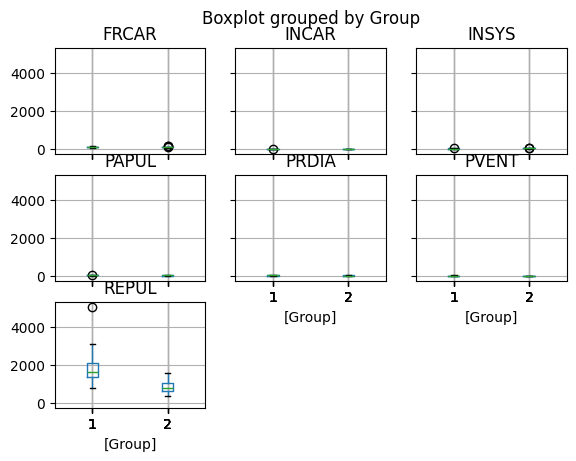

In [ ]:
#Tracer des boxplot de chaque groupe.  
Xdf.select_dtypes(exclude="category").boxplot(by="Group") 

In [38]:
#Calculede la moyenne 
G= Xdf.select_dtypes(exclude="category").groupby('Group').mean() 
print(G)

           FRCAR     INCAR      INSYS      PRDIA      PAPUL      PVENT  \
Group                                                                    
1      95.901961  1.394706  14.996078  21.960784  29.098039  10.647059   
2      88.340000  2.305800  26.752000  16.504000  22.840000   8.330000   

            REPUL  
Group              
1      1797.27451  
2       841.38000  


#### **Etape 2** : Analyse bivariée de couple de variables. 

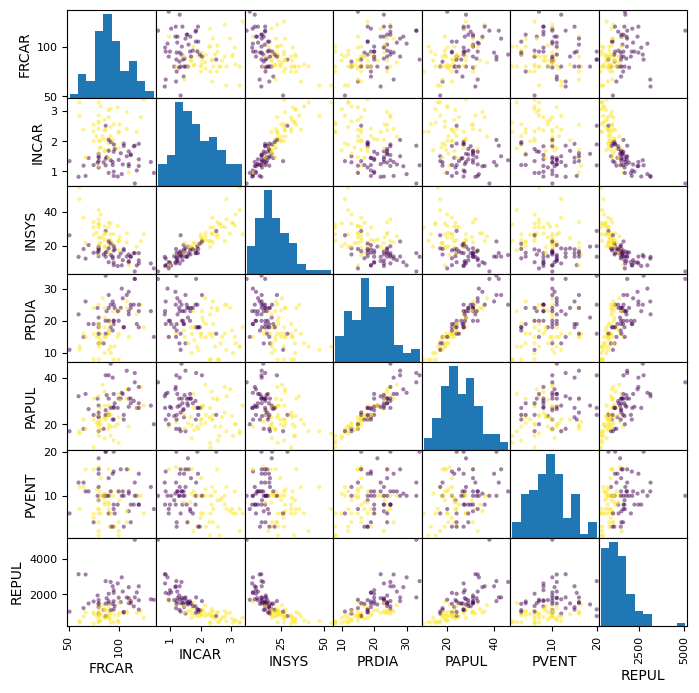

In [39]:
#On trace la matrice des variance covariance. 
pd.plotting.scatter_matrix(Xdf.iloc[:,0:-1],figsize=(8,8),c =Xdf["Group"])  #en mettant le groupe en colormap 
plt.show()

#### **Etape 3** : On fait l'ALD. 

In [40]:
#O calcule les nouvelles coordonnées . 
lda = LinearDiscriminantAnalysis() 
coord_lda = lda.fit_transform(Xdf.select_dtypes(exclude="category").iloc[:,:-1],Xdf['Group']) 


2


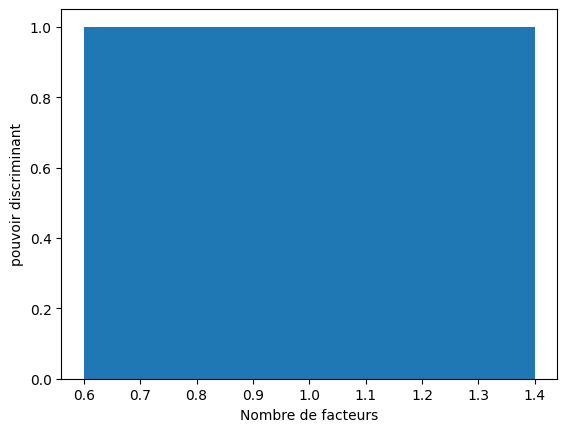

In [49]:
plt.figure() 
# Graphique du pouvoir discriminant de l'axe
nb_axe_dis = len(Xdf["Group"].unique()-1)
print(nb_axe_dis)
plt.bar(np.arange(1, nb_axe_dis), lda.explained_variance_ratio_) 
plt.ylabel("pouvoir discriminant") 
plt.xlabel("Nombre de facteurs") 
plt.show() 


In [51]:
#On trace les individu dans l'espace discriminant
plt.figure(figsize=(16,10))
plt.scatter(coord_lda[:, 0],c = Xdf["Group"])
plt.xlabel('Axe discriminant 1') 
plt.ylabel('Axe discriminant 2') 
#Calcule du centre de gravité de chaque classe dans le plan discriminant. 
passage = lda.scalings_
G2 = (G-Xdf.iloc[:,-1].mean())
G2 = np.dot(G2,passage)
plt.scatter(G2[:,0], G2[:, 1],c = "r")

plt.show()




TypeError: scatter() missing 1 required positional argument: 'y'

<Figure size 1600x1000 with 0 Axes>

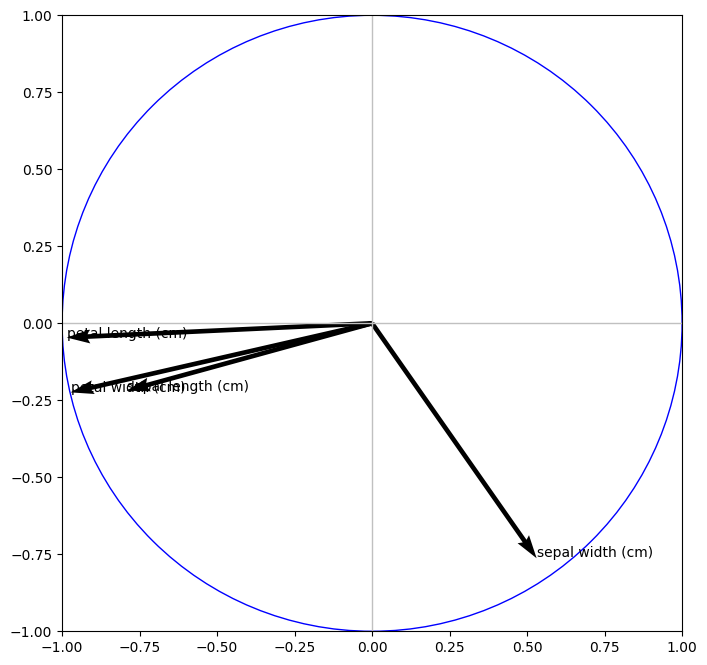

In [ ]:
# Cercle des corrélations 
fig, axes = plt.subplots(figsize=(8, 8)) 
axes.set_xlim(-1, 1) 
axes.set_ylim(-1, 1) 
 
# affichage des étiquettes (noms des variables) 
for j in range(p-1): 
    x = np.corrcoef(Xdf.iloc[:,j],coord_lda[:,0])[0,1] # Correlation entre la variable et le 1er axe discriminant. 
    y = np.corrcoef(Xdf.iloc[:,j],coord_lda[:,1])[0,1] # Correlation entre la variable et le 2e axe discriminant.
    plt.annotate(Xdf.columns[j],(x,y))
    origin = np.array([0,0]) # origin point
    plt.quiver(*origin, [x], [y], color= "black",scale= 2)  
# On ajoute les axes 
plt.plot([-1, 1], [0, 0], color='silver', linestyle='-', linewidth=1) 
plt.plot([0, 0], [-1, 1], color='silver', linestyle='-', linewidth=1) 
# On ajoute un cercle 
cercle = plt.Circle((0, 0), 1, color='blue', fill=False) 
axes.add_artist(cercle) 
plt.show() 